# Lightpanda vs Google Chrome Benchmark Report

Interactive report notebook for comparing browser engine performance over local Express runs (to eliminate network latency issues).

**Benchmark context**
- Workload: 100 iterations against local Express server (network latency minimized)
- Host: Windows 11 Pro
- CPU: 11th Gen Intel(R) Core(TM) i5-1135G7 @ 2.40GHz (4 cores)
- RAM: 16 GB

## 1. Environment Setup and Notebook Parameters

In [10]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Plot and table defaults
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
pd.options.display.float_format = '{:,.3f}'.format

# Parameters
csv_path = Path('../lp-simple-scraper/results/benchmark_surface_express_100runs.csv')
artifacts_dir = Path('report_artifacts')
fig_dir = artifacts_dir / 'figures'
table_dir = artifacts_dir / 'tables'

for folder in [artifacts_dir, fig_dir, table_dir]:
    folder.mkdir(parents=True, exist_ok=True)

rolling_window = 10
expected_rows = 200
expected_iterations = 100
expected_engines = ['Lightpanda', 'Google Chrome']

print(f'CSV path: {csv_path.resolve()}')
print(f'Artifacts dir: {artifacts_dir.resolve()}')

CSV path: C:\Users\Andi\repos\cdas-lightpanda\lp-simple-scraper\results\benchmark_surface_express_100runs.csv
Artifacts dir: C:\Users\Andi\repos\cdas-lightpanda\docs\report_artifacts


## 2. Load CSV

In [11]:
df = pd.read_csv(csv_path, sep=';', decimal=',')
df.columns = [c.strip() for c in df.columns]

numeric_cols = ['ConnectionTimeMs', 'NavigationTimeMs', 'TotalTimeMs', 'MemoryUsageMB']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['Iteration'] = pd.to_numeric(df['Iteration'], errors='coerce').astype('Int64')

# Normalize engine labels
engine_map = {
    'lightpanda': 'Lightpanda',
    'google chrome': 'Google Chrome',
    'chrome': 'Google Chrome'
}
df['Engine'] = (
    df['Engine']
    .astype(str)
    .str.strip()
    .str.lower()
    .map(engine_map)
    .fillna(df['Engine'])
)

df = df.sort_values(['Iteration', 'Engine']).reset_index(drop=True)
df.head()

,Iteration,Engine,ConnectionTimeMs,NavigationTimeMs,TotalTimeMs,MemoryUsageMB
0,1,Google Chrome,54.060,80.740,394.900,81.780
1,1,Lightpanda,81.280,52.390,168.830,5.210
2,2,Google Chrome,28.010,29.920,104.420,91.460
3,2,Lightpanda,23.080,17.690,53.490,5.000
4,3,Google Chrome,42.670,34.230,120.800,101.900


## 3. Data Validation and Quality Checks

In [12]:
row_count = len(df)
iteration_count = df['Iteration'].nunique()
engines_found = sorted(df['Engine'].dropna().unique().tolist())

pair_count = df.groupby('Iteration')['Engine'].nunique()
missing_rows = df[df[numeric_cols + ['Iteration']].isna().any(axis=1)]
duplicates = df.duplicated(subset=['Iteration', 'Engine'], keep=False)
nonpositive = (df[numeric_cols] <= 0).any(axis=1)

print('Rows:', row_count)
print('Unique iterations:', iteration_count)
print('Engines found:', engines_found)
print('Pair completeness (min/max engines per iteration):', pair_count.min(), pair_count.max())
print('Rows with missing values:', len(missing_rows))
print('Duplicate Iteration+Engine rows:', int(duplicates.sum()))
print('Rows with nonpositive timing/memory values:', int(nonpositive.sum()))

assert row_count == expected_rows, f'Expected {expected_rows} rows, got {row_count}'
assert iteration_count == expected_iterations, f'Expected {expected_iterations} iterations, got {iteration_count}'
assert set(expected_engines).issubset(set(engines_found)), 'Expected engines not fully present'
assert pair_count.eq(2).all(), 'Each iteration must have exactly two engine rows'
assert len(missing_rows) == 0, 'Missing values found in required columns'
assert int(duplicates.sum()) == 0, 'Duplicate Iteration+Engine rows found'
assert int(nonpositive.sum()) == 0, 'Nonpositive values found in metric columns'

print('Validation checks passed.')

Rows: 200
Unique iterations: 100
Engines found: ['Google Chrome', 'Lightpanda']
Pair completeness (min/max engines per iteration): 2 2
Rows with missing values: 0
Duplicate Iteration+Engine rows: 0
Rows with nonpositive timing/memory values: 0
Validation checks passed.


## 4. Feature Engineering for Benchmark Metrics

In [13]:
df['ConnectionShare'] = df['ConnectionTimeMs'] / df['TotalTimeMs']
df['NavigationShare'] = df['NavigationTimeMs'] / df['TotalTimeMs']

pivot = df.pivot(index='Iteration', columns='Engine', values=numeric_cols)
pivot.columns = [f'{metric}_{engine}' for metric, engine in pivot.columns]
pivot = pivot.reset_index()

pivot['TotalSpeedup'] = pivot['TotalTimeMs_Google Chrome'] / pivot['TotalTimeMs_Lightpanda']
pivot['ConnectionSpeedup'] = pivot['ConnectionTimeMs_Google Chrome'] / pivot['ConnectionTimeMs_Lightpanda']
pivot['NavigationSpeedup'] = pivot['NavigationTimeMs_Google Chrome'] / pivot['NavigationTimeMs_Lightpanda']
pivot['MemoryRatio'] = pivot['MemoryUsageMB_Google Chrome'] / pivot['MemoryUsageMB_Lightpanda']

pivot['TotalDeltaMs'] = pivot['TotalTimeMs_Google Chrome'] - pivot['TotalTimeMs_Lightpanda']
pivot['MemoryDeltaMB'] = pivot['MemoryUsageMB_Google Chrome'] - pivot['MemoryUsageMB_Lightpanda']

pivot.head()

,Iteration,ConnectionTimeMs_Google Chrome,ConnectionTimeMs_Lightpanda,NavigationTimeMs_Google Chrome,NavigationTimeMs_Lightpanda,TotalTimeMs_Google Chrome,TotalTimeMs_Lightpanda,MemoryUsageMB_Google Chrome,MemoryUsageMB_Lightpanda,TotalSpeedup,ConnectionSpeedup,NavigationSpeedup,MemoryRatio,TotalDeltaMs,MemoryDeltaMB
0,1,54.060,81.280,80.740,52.390,394.900,168.830,81.780,5.210,2.339,0.665,1.541,15.697,226.070,76.570
1,2,28.010,23.080,29.920,17.690,104.420,53.490,91.460,5.000,1.952,1.214,1.691,18.292,50.930,86.460
2,3,42.670,19.260,34.230,16.280,120.800,50.350,101.900,5.500,2.399,2.215,2.103,18.527,70.450,96.400
3,4,59.380,22.450,28.520,19.200,132.820,56.470,112.300,5.680,2.352,2.645,1.485,19.771,76.350,106.620
4,5,50.280,20.220,27.200,21.330,120.090,54.650,123.300,5.310,2.197,2.487,1.275,23.220,65.440,117.990


## 5. Engine-Level Summary Statistics

Compute central tendency, dispersion, tail percentiles, and relative deltas.

In [14]:
metrics = ['ConnectionTimeMs', 'NavigationTimeMs', 'TotalTimeMs', 'MemoryUsageMB']

def p90(x):
    return np.percentile(x, 90)

def p95(x):
    return np.percentile(x, 95)

def p99(x):
    return np.percentile(x, 99)

summary = (
    df.groupby('Engine')[metrics]
    .agg(['mean', 'median', 'min', 'max', 'std', p90, p95, p99])
)
summary.columns = [f'{m}_{s}' for m, s in summary.columns]

for metric in metrics:
    summary[f'{metric}_cv'] = summary[f'{metric}_std'] / summary[f'{metric}_mean']

summary = summary.sort_index()
summary

# Relative delta table using Delta% = (A - B) / B * 100
def delta_percent(a, b):
    return (a - b) / b * 100

lp = summary.loc['Lightpanda']
ch = summary.loc['Google Chrome']

delta_rows = []
for metric in metrics:
    delta_rows.append({
        'Metric': metric,
        'MeanDeltaPct_Chrome_vs_Lightpanda': delta_percent(ch[f'{metric}_mean'], lp[f'{metric}_mean']),
        'MedianDeltaPct_Chrome_vs_Lightpanda': delta_percent(ch[f'{metric}_median'], lp[f'{metric}_median'])
    })

delta_table = pd.DataFrame(delta_rows)
delta_table

,Metric,MeanDeltaPct_Chrome_vs_Lightpanda,MedianDeltaPct_Chrome_vs_Lightpanda
0,ConnectionTimeMs,"2,632.969","2,016.014"
1,NavigationTimeMs,77.754,68.248
2,TotalTimeMs,"1,157.219",873.280
3,MemoryUsageMB,"10,073.559","12,796.758"


## 6. Iteration Charts

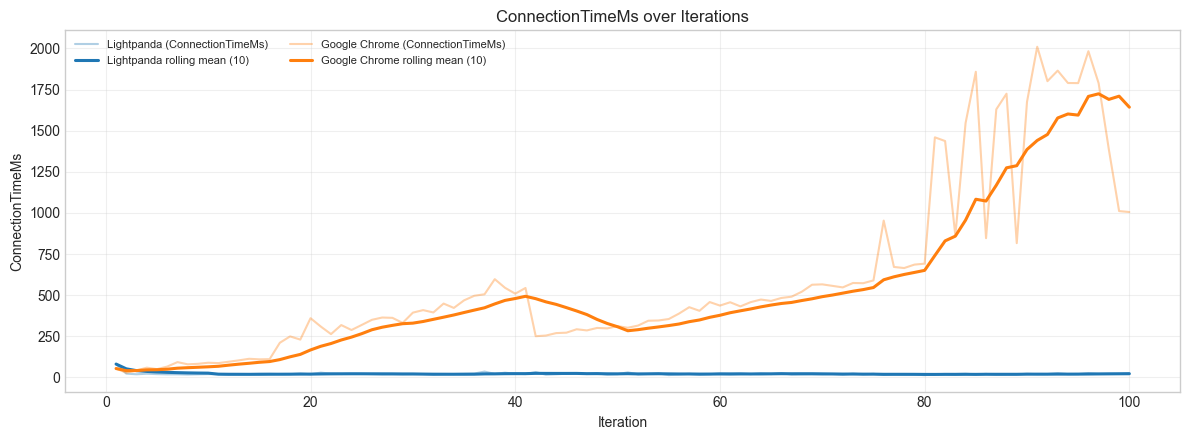

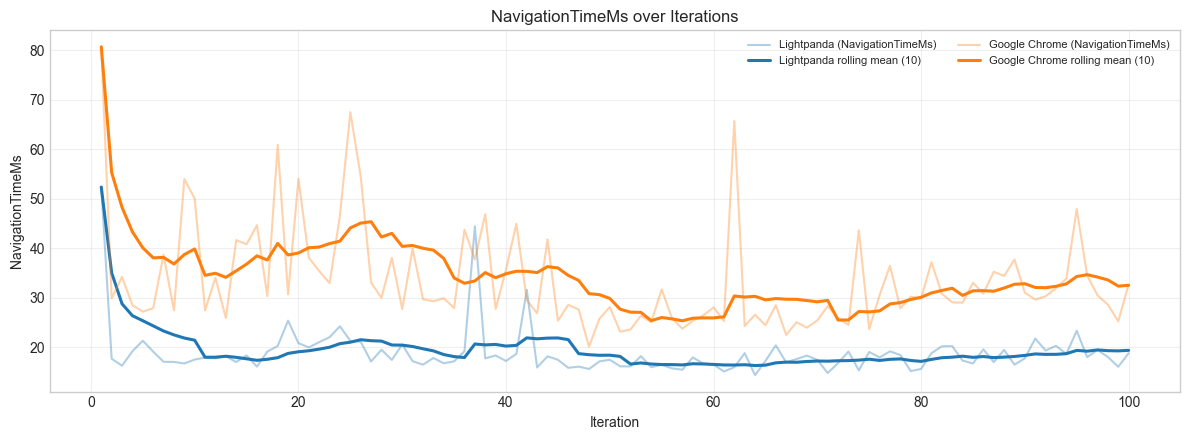

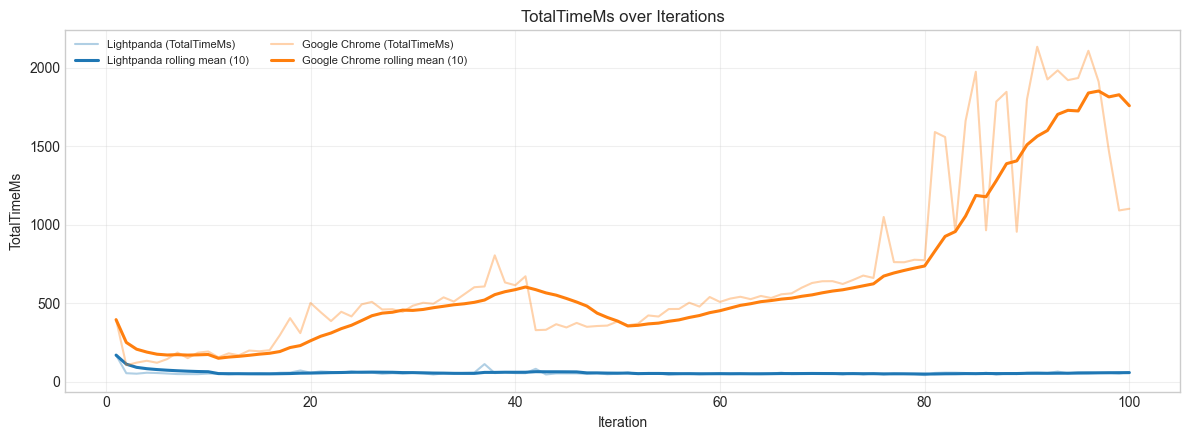

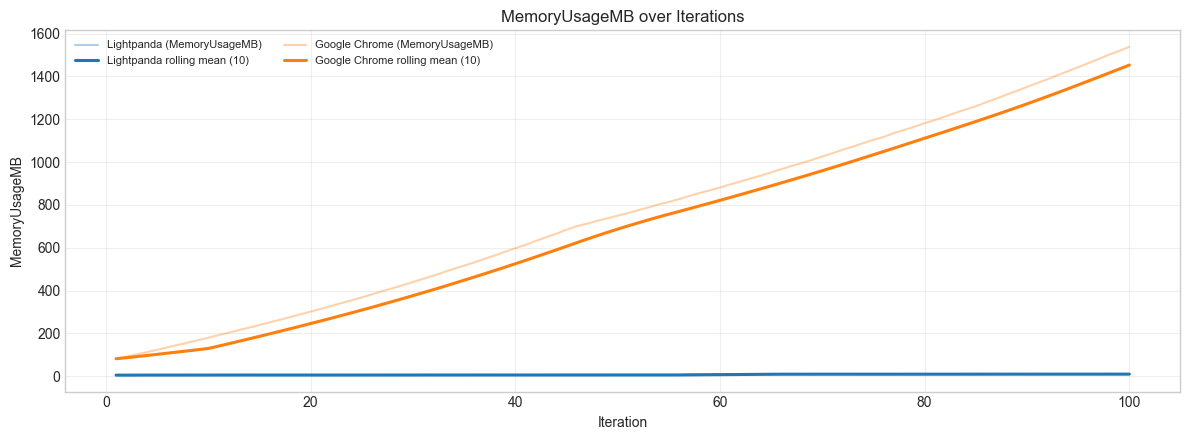

In [15]:
trend_metrics = ['ConnectionTimeMs', 'NavigationTimeMs', 'TotalTimeMs', 'MemoryUsageMB']
colors = {'Lightpanda': '#1f77b4', 'Google Chrome': '#ff7f0e'}

for metric in trend_metrics:
    fig, ax = plt.subplots(figsize=(12, 4.5))
    for engine in expected_engines:
        d = df[df['Engine'] == engine].sort_values('Iteration')
        ax.plot(d['Iteration'], d[metric], alpha=0.35, color=colors[engine], label=f'{engine} ({metric})')
        roll = d[metric].rolling(rolling_window, min_periods=1).mean()
        ax.plot(d['Iteration'], roll, linewidth=2.2, color=colors[engine], label=f'{engine} rolling mean ({rolling_window})')
    ax.set_title(f'{metric} over Iterations')
    ax.set_xlabel('Iteration')
    ax.set_ylabel(metric)
    ax.legend(ncol=2, fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 7. Distribution Charts for Latency and Resource Usage

Boxplots to inspect spread and tail behavior.

C:\Users\Andi\AppData\Local\Temp\ipykernel_15712\2776573236.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=expected_engines, showfliers=True)


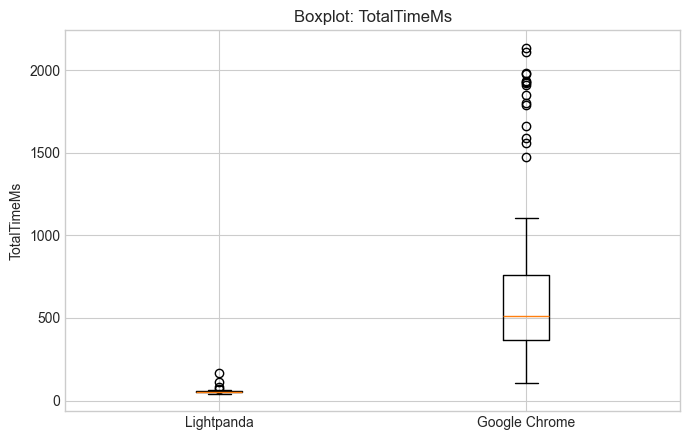

C:\Users\Andi\AppData\Local\Temp\ipykernel_15712\2776573236.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=expected_engines, showfliers=True)


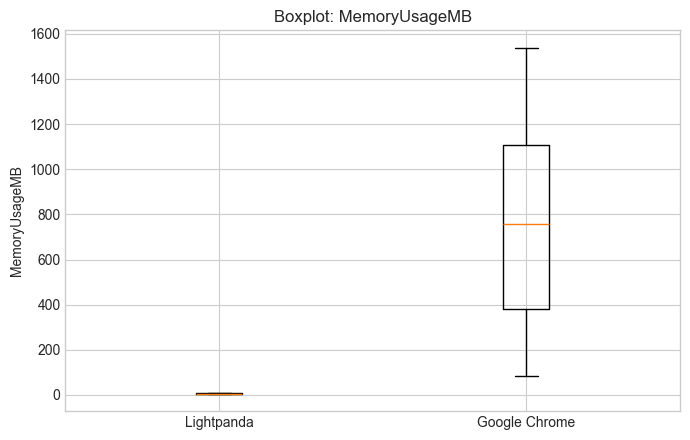

In [16]:
for metric in ['TotalTimeMs', 'MemoryUsageMB']:
    fig, ax = plt.subplots(figsize=(7, 4.5))

    box_data = [df[df['Engine'] == e][metric].values for e in expected_engines]
    ax.boxplot(box_data, labels=expected_engines, showfliers=True)
    ax.set_title(f'Boxplot: {metric}')
    ax.set_ylabel(metric)

    plt.tight_layout()
    plt.show()

## 8. Speedup and Efficiency Analysis

Per-iteration speedups/ratios, geometric mean speedup, win-rate, and phase contribution.

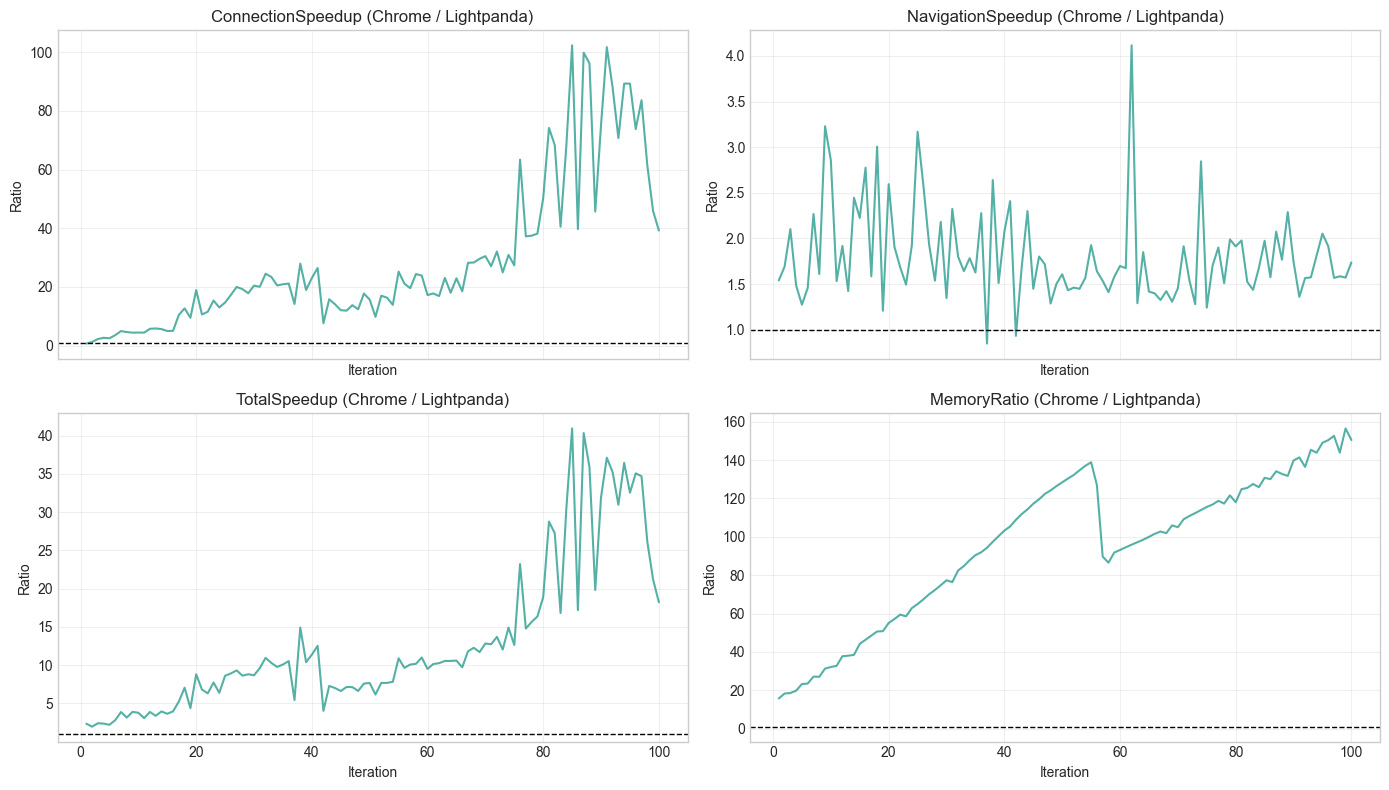

Geometric mean total speedup (Chrome/Lightpanda): 9.871x
Fraction of iterations where Lightpanda total time is lower: 100.00%


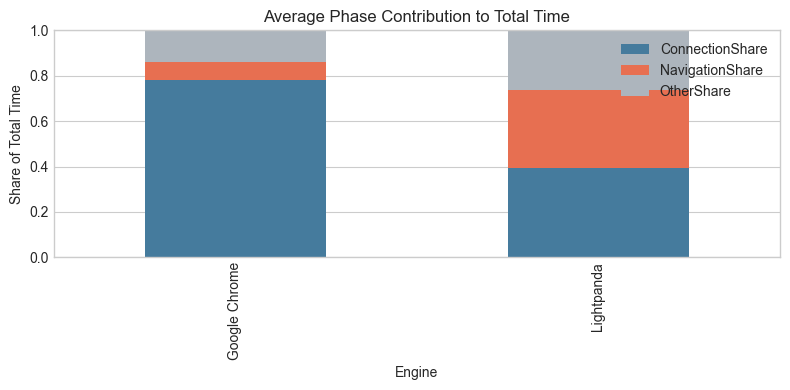

ConnectionTimeMs  NavigationTimeMs  \
Engine        Phase                                                       
Google Chrome Steady-State (11-100)           648.162            32.762   
              Warmup (1-10)                    64.537            39.880   
Lightpanda    Steady-State (11-100)            21.088            18.542   
              Warmup (1-10)                    26.014            21.441   

                                     TotalTimeMs  MemoryUsageMB  
Engine        Phase                                              
Google Chrome Steady-State (11-100)      745.724        827.891  
              Warmup (1-10)              172.787        129.604  
Lightpanda    Steady-State (11-100)       53.854          7.673  
              Warmup (1-10)               62.899          5.459

In [17]:
speedup_cols = ['ConnectionSpeedup', 'NavigationSpeedup', 'TotalSpeedup', 'MemoryRatio']

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
for ax, col in zip(axes.flatten(), speedup_cols):
    ax.plot(pivot['Iteration'], pivot[col], color='#2a9d8f', alpha=0.8)
    ax.axhline(1.0, color='black', linestyle='--', linewidth=1)
    ax.set_title(f'{col} (Chrome / Lightpanda)')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Ratio')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

geo_mean_speedup = float(np.exp(np.log(pivot['TotalSpeedup']).mean()))
lightpanda_win_rate = float((pivot['TotalSpeedup'] > 1).mean())

phase_contrib = df.groupby('Engine')[['ConnectionShare', 'NavigationShare']].mean().copy()
phase_contrib['OtherShare'] = 1 - phase_contrib['ConnectionShare'] - phase_contrib['NavigationShare']

print(f'Geometric mean total speedup (Chrome/Lightpanda): {geo_mean_speedup:.3f}x')
print(f'Fraction of iterations where Lightpanda total time is lower: {lightpanda_win_rate:.2%}')

phase_contrib.plot(kind='bar', stacked=True, figsize=(8, 4), color=['#457b9d', '#e76f51', '#adb5bd'])
plt.title('Average Phase Contribution to Total Time')
plt.ylabel('Share of Total Time')
plt.ylim(0, 1)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Warmup vs steady-state comparison
warmup_cutoff = 10
df['Phase'] = np.where(df['Iteration'] <= warmup_cutoff, 'Warmup (1-10)', 'Steady-State (11-100)')
warmup_summary = df.groupby(['Engine', 'Phase'])[metrics].mean().round(3)
warmup_summary

## 9. Stability Analysis (Rolling Windows and Outliers)

Rolling mean/std diagnostics and outlier detection with IQR thresholds.

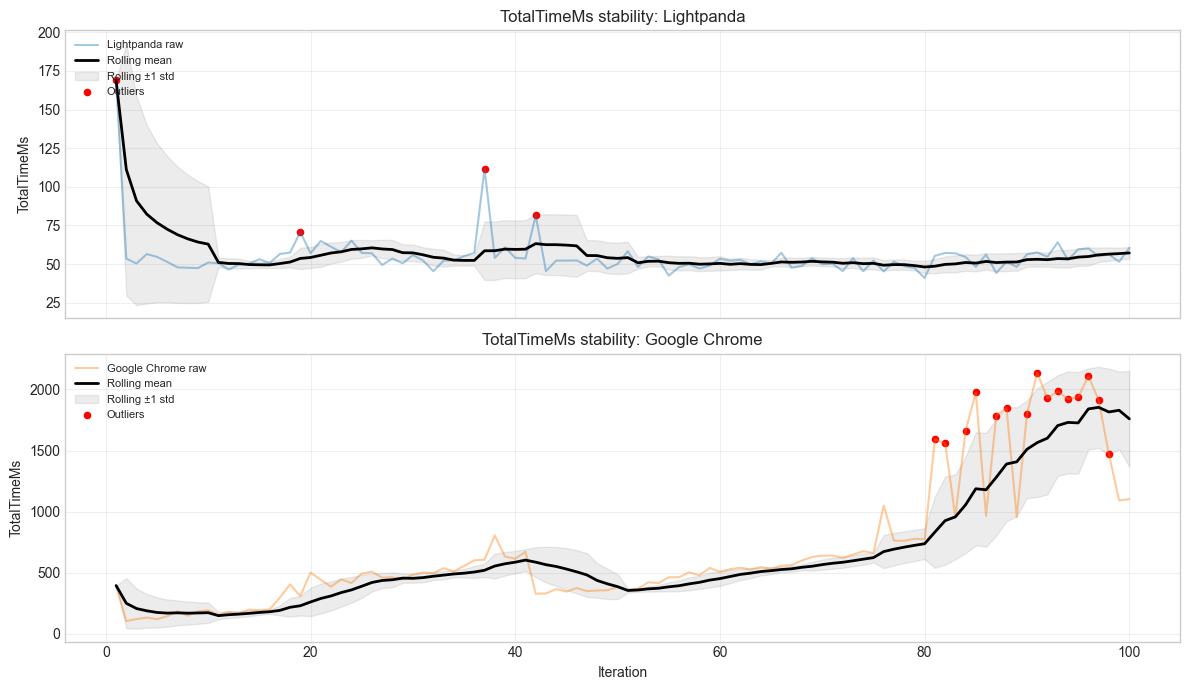

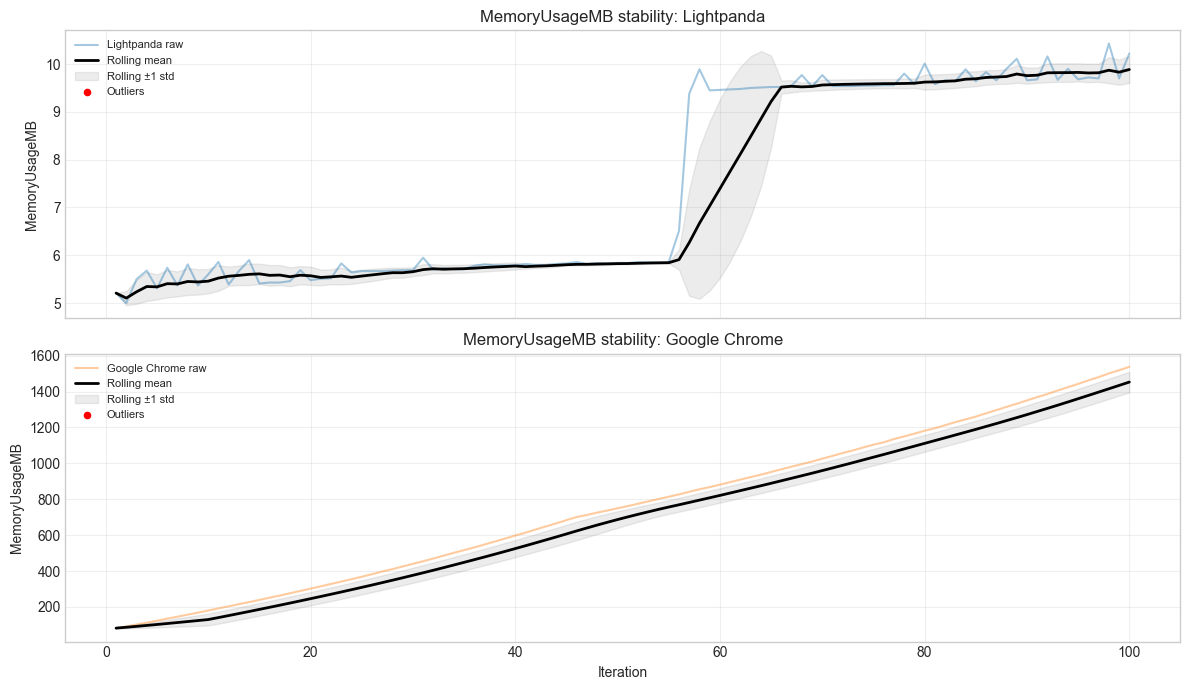

,Engine,Metric,OutlierCount
0,Lightpanda,TotalTimeMs,4
1,Google Chrome,TotalTimeMs,15
2,Lightpanda,MemoryUsageMB,0
3,Google Chrome,MemoryUsageMB,0


In [18]:
def iqr_outlier_mask(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return (series < lower) | (series > upper)

outlier_tables = []
for metric in ['TotalTimeMs', 'MemoryUsageMB']:
    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    for i, engine in enumerate(expected_engines):
        d = df[df['Engine'] == engine].sort_values('Iteration').copy()
        d['roll_mean'] = d[metric].rolling(rolling_window, min_periods=1).mean()
        d['roll_std'] = d[metric].rolling(rolling_window, min_periods=1).std().fillna(0)
        d['is_outlier'] = iqr_outlier_mask(d[metric])

        axes[i].plot(d['Iteration'], d[metric], alpha=0.4, label=f'{engine} raw', color=colors[engine])
        axes[i].plot(d['Iteration'], d['roll_mean'], linewidth=2, label='Rolling mean', color='black')
        axes[i].fill_between(
            d['Iteration'],
            d['roll_mean'] - d['roll_std'],
            d['roll_mean'] + d['roll_std'],
            alpha=0.15,
            color='gray',
            label='Rolling ±1 std'
        )
        out_pts = d[d['is_outlier']]
        axes[i].scatter(out_pts['Iteration'], out_pts[metric], color='red', s=20, label='Outliers')
        axes[i].set_title(f'{metric} stability: {engine}')
        axes[i].set_ylabel(metric)
        axes[i].legend(loc='upper left', fontsize=8)
        axes[i].grid(True, alpha=0.3)

        outlier_tables.append({
            'Engine': engine,
            'Metric': metric,
            'OutlierCount': int(d['is_outlier'].sum())
        })

    axes[-1].set_xlabel('Iteration')
    plt.tight_layout()
    plt.show()

outlier_summary = pd.DataFrame(outlier_tables)
outlier_summary